# Sleep and Daytime Blood Pressure Analysis
## Welltory COVID-19 and Wearables Open Data Research Dataset

### Research Question

**How are sleep duration and sleep onset time associated with daytime blood pressure measured between 10:00 AM and 10:00 PM?**

This analysis investigates two relationships:

1. Sleep duration vs. daytime systolic and diastolic blood pressure
2. Sleep onset time vs. daytime systolic and diastolic blood pressure

The analysis uses `sleep.csv` and `blood_pressure.csv` from the Welltory COVID-19 and Wearables Open Data Research dataset.

This is real-world observational data rather than a controlled random sample. Participants may contribute multiple observations, and missing measurements may result from device usage, synchronization, or differences in data availability. Therefore, observed relationships should be interpreted as associations rather than causal effects.

Blood pressure measurements are restricted to **10:00 AM–10:00 PM** to reduce variation associated with nighttime blood-pressure patterns. Raw data is kept unchanged in the local `data/` directory, and all transformations are documented in this notebook for reproducibility.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/hrv-covid19/data/"

sleep = pd.read_csv(DATA_PATH + "sleep.csv")
bp = pd.read_csv(DATA_PATH + "blood_pressure.csv")

print("Sleep shape:", sleep.shape)
print("Blood pressure shape:", bp.shape)

print("\nSleep columns:")
print(sleep.columns.tolist())

print("\nBlood pressure columns:")
print(bp.columns.tolist())

print("\nSleep preview:")
display(sleep.head())

print("\nBlood pressure preview:")
display(bp.head())

print("\nSleep data types:")
display(sleep.dtypes.to_frame("dtype"))

print("\nBlood pressure data types:")
display(bp.dtypes.to_frame("dtype"))

Sleep shape: (425, 12)
Blood pressure shape: (721, 8)

Sleep columns:
['user_code', 'day', 'sleep_begin', 'sleep_end', 'sleep_duration', 'sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration', 'sleep_deep_duration', 'pulse_min', 'pulse_max', 'pulse_average']

Blood pressure columns:
['user_code', 'measurement_datetime', 'diastolic', 'systolic', 'functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']

Sleep preview:


,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5



Blood pressure preview:


,user_code,measurement_datetime,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
0,01bad5a519,2020-04-29 22:33:33,100,150,NaN,NaN,NaN,NaN
1,01bad5a519,2020-04-30 01:33:33,100,150,NaN,NaN,NaN,NaN
2,01bad5a519,2020-04-30 09:16:38,95,140,3.38,4545.0,6.0,141.4
3,01bad5a519,2020-04-30 12:16:38,95,140,NaN,NaN,NaN,NaN
4,01bad5a519,2020-05-01 06:58:06,80,130,2.89,4000.0,NaN,104.0



Sleep data types:


,dtype
user_code,object
day,object
sleep_begin,object
sleep_end,object
sleep_duration,float64
sleep_awake_duration,float64
sleep_rem_duration,float64
sleep_light_duration,float64
sleep_deep_duration,float64
pulse_min,float64



Blood pressure data types:


,dtype
user_code,object
measurement_datetime,object
diastolic,int64
systolic,int64
functional_changes_index,float64
circulatory_efficiency,float64
kerdo_vegetation_index,float64
robinson_index,float64


In [14]:
def missing_summary(df):
    return pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2)
    }).sort_values("missing_percent", ascending=False)

print("SLEEP — Missing values")
display(missing_summary(sleep))

print("BLOOD PRESSURE — Missing values")
display(missing_summary(bp))

print("Exact duplicate sleep rows:", sleep.duplicated().sum())
print("Exact duplicate BP rows:", bp.duplicated().sum())

print("\nSleep descriptive statistics:")
display(sleep.describe(include="all").T)

print("\nBlood pressure descriptive statistics:")
display(bp.describe(include="all").T)

SLEEP — Missing values


,missing_count,missing_percent
sleep_rem_duration,418,98.35
sleep_awake_duration,416,97.88
sleep_deep_duration,411,96.71
pulse_min,410,96.47
pulse_max,410,96.47
pulse_average,410,96.47
sleep_light_duration,398,93.65
user_code,0,0.00
sleep_end,0,0.00
sleep_begin,0,0.00


BLOOD PRESSURE — Missing values


,missing_count,missing_percent
kerdo_vegetation_index,438,60.75
robinson_index,422,58.53
functional_changes_index,422,58.53
circulatory_efficiency,422,58.53
systolic,0,0.00
diastolic,0,0.00
measurement_datetime,0,0.00
user_code,0,0.00


Exact duplicate sleep rows: 0
Exact duplicate BP rows: 0

Sleep descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,425,10,6be5033971,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,425,154,2020-05-19,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_begin,425,424,2020-05-19 00:03:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_end,425,425,2020-05-07 06:33:25,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_duration,425.0,NaN,NaN,NaN,25699.731765,7773.80547,930.0,21857.0,26041.0,30600.0,47460.0
sleep_awake_duration,9.0,NaN,NaN,NaN,2733.333333,671.90029,1740.0,2460.0,2490.0,2790.0,4200.0
sleep_rem_duration,7.0,NaN,NaN,NaN,6518.571429,2081.613385,2820.0,5730.0,6240.0,8190.0,8730.0
sleep_light_duration,27.0,NaN,NaN,NaN,14514.740741,8078.12629,300.0,7995.0,17340.0,20340.0,23100.0
sleep_deep_duration,14.0,NaN,NaN,NaN,4280.285714,2089.766547,480.0,2797.5,4230.0,5550.0,7934.0
pulse_min,15.0,NaN,NaN,NaN,60.533333,12.844491,52.0,54.5,58.0,60.0,105.0



Blood pressure descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,721,28,a1c2e6b2eb,333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measurement_datetime,721,719,2020-05-10 21:27:56,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diastolic,721.0,NaN,NaN,NaN,81.228849,8.865761,25.0,76.0,82.0,88.0,101.0
systolic,721.0,NaN,NaN,NaN,119.441054,10.522578,63.0,113.0,120.0,126.0,157.0
functional_changes_index,299.0,NaN,NaN,NaN,2.594013,0.291302,1.68,2.44,2.58,2.73,3.51
circulatory_efficiency,299.0,NaN,NaN,NaN,2735.197057,747.88257,1300.0,2250.5,2640.0,3076.5,7875.0
kerdo_vegetation_index,283.0,NaN,NaN,NaN,-15.498233,18.681233,-76.0,-29.0,-17.0,-5.0,45.0
robinson_index,299.0,NaN,NaN,NaN,84.663779,14.399208,49.5,75.58,83.22,93.17,164.85


## Data Quality and Cleaning Strategy

Before analyzing the relationship between sleep and blood pressure, I assess missing values, duplicates, data types, and descriptive statistics.

I do not automatically impute missing physiological measurements because replacing them with averages could create artificial health observations. Instead, complete observations are used for the variables required in the final relationship analysis.

Exact duplicate rows are removed because they could give individual measurements unintended extra weight. Repeated observations from the same participant on different dates are retained because they are legitimate longitudinal observations.

Date and time variables are converted to datetime formats before merging the datasets. Blood pressure measurements are aggregated to the participant-day level because some participants have multiple measurements on the same day.

Potential outliers are inspected rather than automatically removed because extreme physiological values may represent either real variation or measurement error.

In [15]:
# Remove exact duplicates
sleep_clean = sleep.drop_duplicates().copy()
bp_clean = bp.drop_duplicates().copy()

# ---------- SLEEP DATA ----------

sleep_clean["day"] = pd.to_datetime(
    sleep_clean["day"], errors="coerce"
).dt.normalize()

sleep_clean["sleep_begin_dt"] = pd.to_datetime(
    sleep_clean["sleep_begin"], errors="coerce"
)

# Convert sleep duration to hours
median_duration = sleep_clean["sleep_duration"].median()

if median_duration > 1000:
    sleep_clean["sleep_hours"] = sleep_clean["sleep_duration"] / 3600
elif median_duration > 24:
    sleep_clean["sleep_hours"] = sleep_clean["sleep_duration"] / 60
else:
    sleep_clean["sleep_hours"] = sleep_clean["sleep_duration"]

# Convert bedtime to continuous hour
sleep_clean["sleep_onset_hour"] = (
    sleep_clean["sleep_begin_dt"].dt.hour
    + sleep_clean["sleep_begin_dt"].dt.minute / 60
)

# Make times after midnight continuous with the previous evening
sleep_clean.loc[
    sleep_clean["sleep_onset_hour"] < 12,
    "sleep_onset_hour"
] += 24


# ---------- BLOOD PRESSURE DATA ----------

bp_clean["measurement_datetime"] = pd.to_datetime(
    bp_clean["measurement_datetime"], errors="coerce"
)

bp_clean["measurement_hour"] = (
    bp_clean["measurement_datetime"].dt.hour
    + bp_clean["measurement_datetime"].dt.minute / 60
)

bp_clean["day"] = (
    bp_clean["measurement_datetime"].dt.normalize()
)

# Keep only daytime measurements: 10 AM to 10 PM
bp_daytime = bp_clean[
    (bp_clean["measurement_hour"] >= 10) &
    (bp_clean["measurement_hour"] <= 22)
].copy()


# ---------- DAILY AGGREGATION ----------

sleep_daily = (
    sleep_clean
    .groupby(["user_code", "day"], as_index=False)
    .agg(
        sleep_hours=("sleep_hours", "mean"),
        sleep_onset_hour=("sleep_onset_hour", "mean")
    )
)

bp_daily = (
    bp_daytime
    .groupby(["user_code", "day"], as_index=False)
    .agg(
        daytime_systolic=("systolic", "mean"),
        daytime_diastolic=("diastolic", "mean"),
        bp_measurement_count=("systolic", "count")
    )
)


# ---------- MERGE ----------

merged = pd.merge(
    sleep_daily,
    bp_daily,
    on=["user_code", "day"],
    how="inner",
    validate="one_to_one"
)

analysis_df = merged.dropna(
    subset=[
        "sleep_hours",
        "sleep_onset_hour",
        "daytime_systolic",
        "daytime_diastolic"
    ]
).copy()

print("Original sleep rows:", len(sleep))
print("Original BP rows:", len(bp))
print("Daytime BP rows retained:", len(bp_daytime))
print("Matched participant-days:", len(merged))
print("Complete observations for analysis:", len(analysis_df))
print("Unique participants:", analysis_df["user_code"].nunique())

display(analysis_df.head())

Original sleep rows: 425
Original BP rows: 721
Daytime BP rows retained: 403
Matched participant-days: 39
Complete observations for analysis: 39
Unique participants: 3


,user_code,day,sleep_hours,sleep_onset_hour,daytime_systolic,daytime_diastolic,bp_measurement_count
0,0d297d2410,2020-01-13,5.250000,25.250000,127.0,82.0,2
1,6be5033971,2020-01-24,3.916667,12.250000,126.0,77.0,1
2,6be5033971,2020-05-15,8.750000,23.083333,112.0,77.0,2
3,6be5033971,2020-05-16,8.166667,22.916667,110.0,70.0,2
4,6be5033971,2020-05-18,10.166667,21.583333,119.0,80.0,1


## Data Transformation and Feature Engineering

The two datasets are transformed to a common **participant-day** unit before analysis.

Blood pressure measurements are restricted to 10:00 AM–10:00 PM. When multiple measurements occur for the same participant on the same day, their mean systolic and diastolic blood pressure is calculated so that days with more measurements do not receive disproportionate weight.

Two analysis-ready sleep features are created:

- `sleep_hours`: sleep duration converted into hours
- `sleep_onset_hour`: sleep onset represented as a continuous numerical time

Sleep onset requires special treatment because clock time wraps around at midnight. For example, 11:30 PM and 12:30 AM are only one hour apart even though their ordinary numerical representations are 23.5 and 0.5. Therefore, after-midnight sleep times are shifted forward by 24 hours:

- 10:00 PM → 22.0
- 11:30 PM → 23.5
- 12:30 AM → 24.5
- 2:00 AM → 26.0

These transformations make both sleep duration and sleep onset suitable for numerical relationship analysis.

In [16]:
print("Final analysis descriptive statistics:")
display(
    analysis_df[
        [
            "sleep_hours",
            "sleep_onset_hour",
            "daytime_systolic",
            "daytime_diastolic"
        ]
    ].describe().T
)

# IQR-based outlier assessment
variables = [
    "sleep_hours",
    "sleep_onset_hour",
    "daytime_systolic",
    "daytime_diastolic"
]

outlier_results = []

for col in variables:
    q1 = analysis_df[col].quantile(0.25)
    q3 = analysis_df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = (
        (analysis_df[col] < lower) |
        (analysis_df[col] > upper)
    ).sum()

    outlier_results.append({
        "variable": col,
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "potential_outliers": count
    })

display(pd.DataFrame(outlier_results))

Final analysis descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
sleep_hours,39.0,6.415520,2.091243,3.033333,4.750000,6.083333,8.041667,10.916667
sleep_onset_hour,39.0,22.801282,2.779760,12.250000,21.916667,23.066667,24.308333,28.000000
daytime_systolic,39.0,119.511966,5.687245,110.000000,116.500000,119.000000,122.125000,135.000000
daytime_diastolic,39.0,82.858974,5.670304,70.000000,79.250000,82.000000,87.500000,94.000000


,variable,lower_bound,upper_bound,potential_outliers
0,sleep_hours,-0.19,12.98,0
1,sleep_onset_hour,18.33,27.90,4
2,daytime_systolic,108.06,130.56,1
3,daytime_diastolic,66.88,99.88,0


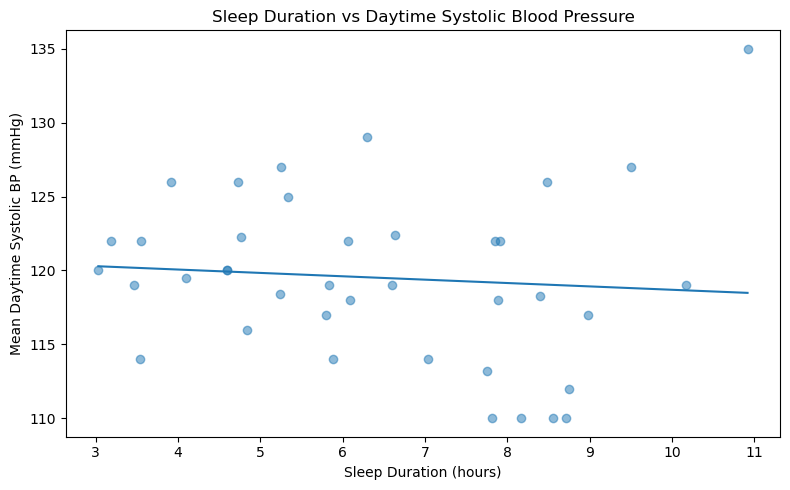

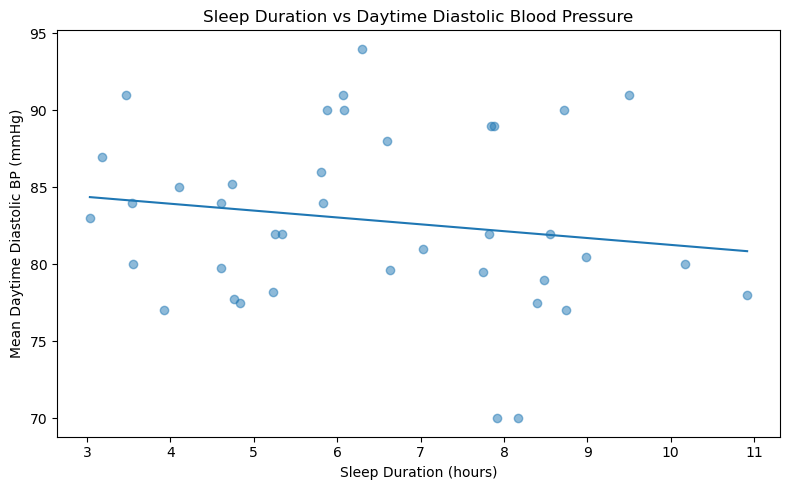

In [17]:
# Sleep duration vs systolic BP
plt.figure(figsize=(8, 5))

x = analysis_df["sleep_hours"]
y = analysis_df["daytime_systolic"]

plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b)

plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Mean Daytime Systolic BP (mmHg)")
plt.title("Sleep Duration vs Daytime Systolic Blood Pressure")
plt.tight_layout()
plt.show()


# Sleep duration vs diastolic BP
plt.figure(figsize=(8, 5))

y = analysis_df["daytime_diastolic"]

plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x_line, m * x_line + b)

plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Mean Daytime Diastolic BP (mmHg)")
plt.title("Sleep Duration vs Daytime Diastolic Blood Pressure")
plt.tight_layout()
plt.show()

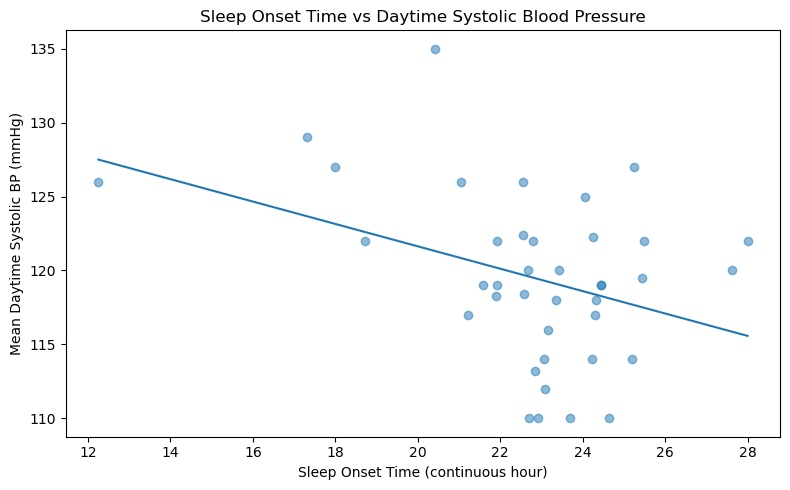

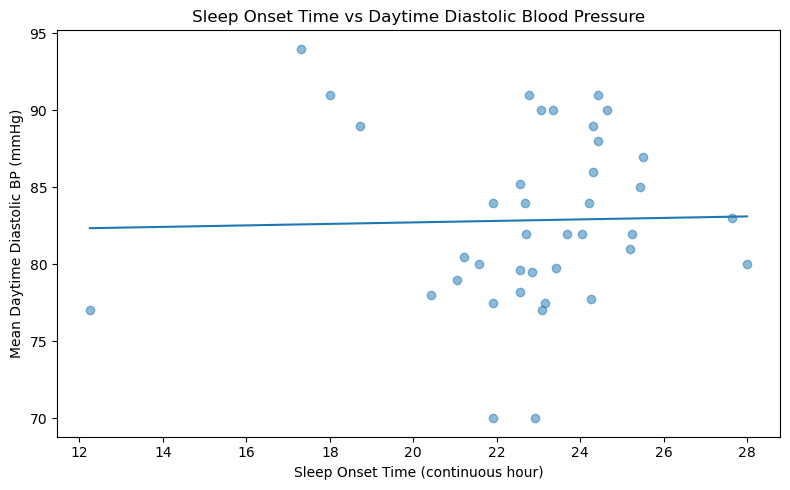

In [18]:
# Sleep onset vs systolic BP
plt.figure(figsize=(8, 5))

x = analysis_df["sleep_onset_hour"]
y = analysis_df["daytime_systolic"]

plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m * x_line + b)

plt.xlabel("Sleep Onset Time (continuous hour)")
plt.ylabel("Mean Daytime Systolic BP (mmHg)")
plt.title("Sleep Onset Time vs Daytime Systolic Blood Pressure")
plt.tight_layout()
plt.show()


# Sleep onset vs diastolic BP
plt.figure(figsize=(8, 5))

y = analysis_df["daytime_diastolic"]

plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x_line, m * x_line + b)

plt.xlabel("Sleep Onset Time (continuous hour)")
plt.ylabel("Mean Daytime Diastolic BP (mmHg)")
plt.title("Sleep Onset Time vs Daytime Diastolic Blood Pressure")
plt.tight_layout()
plt.show()

In [19]:
relationships = pd.DataFrame({
    "Relationship": [
        "Sleep duration vs daytime systolic BP",
        "Sleep duration vs daytime diastolic BP",
        "Sleep onset time vs daytime systolic BP",
        "Sleep onset time vs daytime diastolic BP"
    ],
    "Pearson correlation": [
        analysis_df["sleep_hours"].corr(
            analysis_df["daytime_systolic"]
        ),
        analysis_df["sleep_hours"].corr(
            analysis_df["daytime_diastolic"]
        ),
        analysis_df["sleep_onset_hour"].corr(
            analysis_df["daytime_systolic"]
        ),
        analysis_df["sleep_onset_hour"].corr(
            analysis_df["daytime_diastolic"]
        )
    ]
})

relationships["Pearson correlation"] = (
    relationships["Pearson correlation"].round(3)
)

display(relationships)

,Relationship,Pearson correlation
0,Sleep duration vs daytime systolic BP,-0.084
1,Sleep duration vs daytime diastolic BP,-0.164
2,Sleep onset time vs daytime systolic BP,-0.370
3,Sleep onset time vs daytime diastolic BP,0.024


## Results and Interpretation

The relationships between sleep and daytime blood pressure were evaluated using scatter plots, linear trend lines, and Pearson correlation coefficients.

### Sleep duration and daytime blood pressure

The relationship between sleep duration and both systolic and diastolic daytime blood pressure is evaluated using the direction of the trend line, the magnitude of the correlation coefficient, and the amount of variation visible in the scatter plots.

### Sleep onset time and daytime blood pressure

Sleep onset time is analyzed in the same way. A positive correlation would indicate that later sleep onset tends to be associated with higher daytime blood pressure, while a negative correlation would indicate the opposite.

The magnitude of each correlation is important. A visible trend does not necessarily imply a strong relationship if observations are widely dispersed.

Because multiple observations may come from the same participants, these relationships should be interpreted as exploratory associations rather than causal effects.

## Data Quality Assessment and Discussion

### Completeness
Both source datasets contain missing values. Missing physiological values were not automatically imputed because doing so could create artificial measurements. The final relationship analysis uses observations with the required sleep and blood pressure variables available.

### Accuracy
Potential outliers were identified using the IQR method. Extreme physiological observations were flagged rather than automatically removed because unusual values may represent either genuine physiological variation or measurement error.

### Consistency
Dates and timestamps were converted into standardized datetime formats. Blood pressure was restricted to a consistent daytime window of 10:00 AM–10:00 PM.

### Integrity
Sleep and blood pressure observations were merged using both anonymized participant ID and calendar date. Daily aggregation ensured one observation per participant-day before merging.

### Lineage and Provenance
The analysis uses the original Welltory COVID-19 and Wearables Open Data Research files stored locally in the `data/` directory. Raw source files were not modified. All transformations and feature engineering are documented in this notebook.

### Limitations
This is observational data with repeated measurements from participants. Blood pressure can also be influenced by factors not controlled here, including age, health conditions, medication, physical activity, stress, caffeine consumption, and the exact time of blood pressure measurement.

Therefore, associations between sleep and daytime blood pressure should not be interpreted as evidence that sleep duration or bedtime directly causes blood pressure changes.

## Conclusion

This analysis examines whether two sleep characteristics — **sleep duration** and **sleep onset time** — are associated with systolic and diastolic blood pressure measured during daytime hours.

The final interpretation is based on the observed scatter plots and correlation coefficients. The analysis demonstrates how two messy real-world health datasets can be cleaned, transformed, integrated, visualized, and evaluated while preserving clear data lineage and documenting the rationale for major preprocessing decisions.